<a href="https://colab.research.google.com/github/Mru321/CSI-Cross-Environment-Generalization/blob/main/CNN%20%2B%20Transformer%20Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    ReLU,
    Dropout,
    Dense,
    GlobalAveragePooling1D,
    GlobalMaxPooling1D,
    Concatenate,
    MultiHeadAttention,
    LayerNormalization,
    Add
)

from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [2]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

RAW_DIR = "/content/drive/MyDrive/Project/Project1/raw_data/renew_dataset/tvt_open_source/raw_traces"
PROCESSED_DIR = "/content/drive/MyDrive/Project/Project1/processed"

In [4]:
import os
import numpy as np

files = sorted([f for f in os.listdir(PROCESSED_DIR) if f.endswith(".npy")])

file_info = []

for f in files:
    path = os.path.join(PROCESSED_DIR, f)

    label = 0 if "NLOS" in f else 1

    # FIXED env extraction
    env = f.replace(".npy", "")

    file_info.append((path, label, env))

In [5]:
train_envs = [
    "channe14_LOS_cluster1",
    "channe14_LOS_cluster2",
    "channe14_NLOS_cluster1",
    "channe14_NLOS_cluster2",
    "channe14_NLOS_cluster3"
]

test_envs = [
    "channe14_LOS_cluster3",
    "channe14_LOS_cluster4",
    "channe14_NLOS_cluster4",
    "channe14_NLOS_cluster5"
]

In [6]:
X_train_list = []
y_train_list = []

X_test_list = []
y_test_list = []

for path, label, env in file_info:

    data = np.load(path)

    # TRAIN
    if env in train_envs:

        X_train_list.append(data)

        y_train_list.append(
            np.full((data.shape[0],), label)
        )

    # TEST
    elif env in test_envs:

        X_test_list.append(data)

        y_test_list.append(
            np.full((data.shape[0],), label)
        )

In [7]:
X_train = np.vstack(X_train_list)
y_train = np.hstack(y_train_list)

X_test = np.vstack(X_test_list)
y_test = np.hstack(y_test_list)

In [8]:
X_train = X_train.reshape(X_train.shape[0], 72, 1)
X_test = X_test.reshape(X_test.shape[0], 72, 1)

In [17]:
# ============================================================
# TRANSFORMER ENCODER
# ============================================================

def transformer_encoder(
    inputs,
    head_size=32,
    num_heads=2,
    ff_dim=64,
    dropout=0.1
):

    # ========================================================
    # MULTI HEAD SELF ATTENTION
    # ========================================================

    attention = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    attention = Dropout(dropout)(attention)

    attention = Add()([inputs, attention])

    attention = LayerNormalization(
        epsilon=1e-6
    )(attention)

    # ========================================================
    # FEED FORWARD NETWORK
    # ========================================================

    ff = Dense(
        ff_dim,
        activation='relu'
    )(attention)

    ff = Dropout(dropout)(ff)

    ff = Dense(
        inputs.shape[-1]
    )(ff)

    ff = Add()([attention, ff])

    output = LayerNormalization(
        epsilon=1e-6
    )(ff)

    return output

In [18]:
# ============================================================
# CNN + TRANSFORMER MODEL
# ============================================================

def build_cnn_transformer():

    # ========================================================
    # INPUT
    # ========================================================

    inputs = Input(shape=(72,1))

    # ========================================================
    # CNN BLOCK 1
    # ========================================================

    x = Conv1D(
        filters=64,
        kernel_size=3,
        padding='same'
    )(inputs)

    x = BatchNormalization()(x)

    x = ReLU()(x)

    # ========================================================
    # CNN BLOCK 2
    # ========================================================

    x = Conv1D(
        filters=128,
        kernel_size=3,
        padding='same'
    )(x)

    x = BatchNormalization()(x)

    x = ReLU()(x)

    x = Dropout(0.2)(x)

    # ========================================================
    # SINGLE TRANSFORMER BLOCK
    # ========================================================

    x = transformer_encoder(
        x,
        head_size=32,
        num_heads=2,
        ff_dim=64,
        dropout=0.1
    )

    # ========================================================
    # GLOBAL POOLING
    # ========================================================

    x = GlobalAveragePooling1D()(x)

    # ========================================================
    # DENSE LAYERS
    # ========================================================

    x = Dense(
        128,
        activation='relu'
    )(x)

    x = Dropout(0.3)(x)

    x = Dense(
        64,
        activation='relu'
    )(x)

    x = Dropout(0.2)(x)

    # ========================================================
    # OUTPUT
    # ========================================================

    outputs = Dense(
        1,
        activation='sigmoid'
    )(x)

    # ========================================================
    # MODEL
    # ========================================================

    model = Model(
        inputs,
        outputs
    )

    return model

In [19]:
model = build_stable_cnn_transformer()

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 72, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 72, 64)    │        256 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 72, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 72, 128)   │     24,704 │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 128)   │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 72, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 72, 128)   │          0 │ re_lu_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 72, 128)   │     49,280 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 128)   │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 72, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 72, 128)   │     49,280 │ re_lu_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 128)   │        512 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 72, 128)   │          0 │ dropout_6[0][0],  │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 72, 128)   │          0 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 72, 128)   │     33,088 │ re_lu_7[0][0],    │
│ (MultiHeadAttentio… │                   │            │ re_lu_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 72, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 72, 128)   │          0 │ re_lu_7[0][0],    │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 72, 128)   │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 72, 64)    │      8,256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 216,705 (846.50 KB)

 Trainable params: 215,809 (843.00 KB)

 Non-trainable params: 896 (3.50 KB)

In [20]:
# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(

    optimizer=Adam(
        learning_rate=0.00005
    ),

    loss='binary_crossentropy',

    metrics=['accuracy']
)

In [21]:
# ============================================================
# CALLBACKS
# ============================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [22]:
# ============================================================
# CLASS WEIGHTS
# ============================================================

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, class_weights)
)

print(class_weights)

{np.int64(0): np.float64(1.0741915028535194), np.int64(1): np.float64(0.9353948094975152)}


In [23]:
# ============================================================
# TRAIN MODEL
# ============================================================

history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_test,
        y_test
    ),

    epochs=20,

    batch_size=128,

    shuffle=True,

    class_weight=class_weights,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],

    verbose=1
)

Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.7210 - loss: 0.5486
Epoch 1: val_accuracy improved from None to 0.68068, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 170s 676ms/step - accuracy: 0.8573 - loss: 0.3185 - val_accuracy: 0.6807 - val_loss: 0.8485 - learning_rate: 5.0000e-05
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.9924 - loss: 0.0399
Epoch 2: val_accuracy improved from 0.68068 to 0.73534, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 142s 593ms/step - accuracy: 0.9948 - loss: 0.0285 - val_accuracy: 0.7353 - val_loss: 0.7133 - learning_rate: 5.0000e-05
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.9979 - loss: 0.0115
Epoch 3: val_accuracy did not improve from 0.73534
239/239 ━━━━━━━━━━━━━━━━━━━━ 160s 668ms/step - accuracy: 0.9985 - loss: 0.0091 - val_accuracy: 0.6958 - val_

In [24]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

761/761 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.7353 - loss: 0.7133
Test Loss : 0.7132569551467896
Test Accuracy : 0.7353388667106628


In [25]:
# ============================================================
# PREDICTIONS
# ============================================================

predictions = model.predict(X_test)

predicted_labels = (
    predictions > 0.5
).astype(int)

761/761 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step


In [26]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

cm = confusion_matrix(
    y_test,
    predicted_labels
)

print(cm)

print(
    classification_report(
        y_test,
        predicted_labels
    )
)

[[7956  164]
 [6276 9937]]
              precision    recall  f1-score   support

           0       0.56      0.98      0.71      8120
           1       0.98      0.61      0.76     16213

    accuracy                           0.74     24333
   macro avg       0.77      0.80      0.73     24333
weighted avg       0.84      0.74      0.74     24333



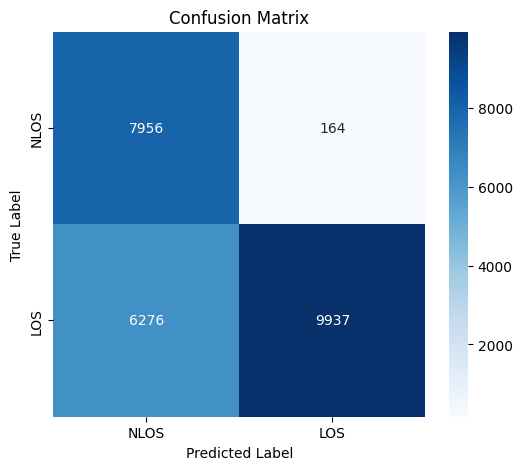

In [27]:
# ============================================================
# PLOT CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NLOS','LOS'],
    yticklabels=['NLOS','LOS']
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

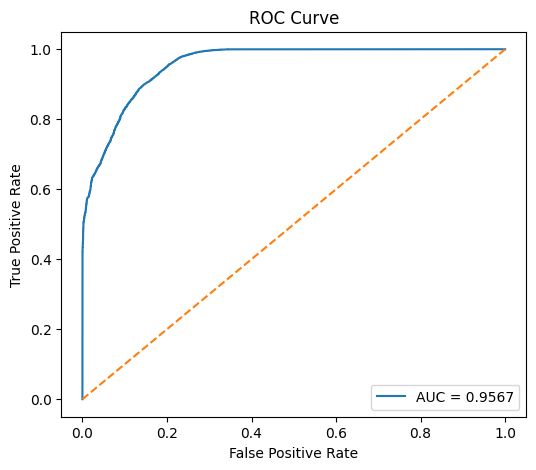

AUC Score : 0.9567038051627365


In [28]:
# ============================================================
# ROC CURVE
# ============================================================

from sklearn.metrics import roc_curve
from sklearn.metrics import auc

fpr, tpr, thresholds = roc_curve(
    y_test,
    predictions
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC Score :", roc_auc)

In [29]:
model.save("cnn_transformer_model_1.keras")

In [30]:
from google.colab import files

files.download(
    "cnn_transformer_model_1.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>